In [219]:
%load_ext autoreload
%autoreload 2

import jax.numpy as jnp
import scipy
import matplotlib.pyplot as plt

import rksd.metrics as metrics
import rksd.kernels as kernels
import rksd.exp_utils as exp_utils
import os
import pickle
from scipy.optimize import minimize as sci_minimize
import pandas as pd
import seaborn as sns
from tqdm.notebook import tqdm, trange

plt.rcParams["mathtext.fontset"] = "cm"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [248]:
np.random.seed(2024)

/home/clustor/ma/x/xl6116/research/robust-kernel-test/rksd/metrics.py:166: SyntaxWarning: invalid escape sequence '\g'
  """


In [249]:
# SAVE_DIR = "../data/ms"

# X_res = pickle.load(open(os.path.join(SAVE_DIR, f"X_res_n500_d1.pkl"), "rb"))
# score_res = pickle.load(open(os.path.join(SAVE_DIR, f"score_res_n500_d1.pkl"), "rb"))

In [250]:
ms = 0.
dim = 1
n = 500

xs = np.random.multivariate_normal(np.zeros(dim), np.eye(dim), n)
score_fn = lambda x: - (x - np.array([[ms]]))
scores = score_fn(xs)

In [251]:
weight_fn = kernels.PolyWeightFunction()
kernel0 = kernels.IMQ(**{"sigma_sq": None, "med_heuristic": True, "X": xs, "Y": xs})
kernel = kernels.TiltedKernel(kernel=kernel0, weight_fn=weight_fn)

ksd = metrics.KSD(kernel)

In [260]:
vstat = ksd(xs, xs, vstat=True, score=scores)

In [253]:
eps0 = 0.05
theta = None
alpha = 0.05
tau_infty = "auto"
wild = False

thresh_res = ksd.test_threshold(
    X=xs, 
    score=scores, 
    eps0=eps0, 
    theta=theta, 
    alpha=alpha, 
    tau_infty=tau_infty, 
    wild=wild,
)

In [254]:
tau = thresh_res["tau"]
n = xs.shape[0]

dev_threshold = ksd.compute_deviation_threshold(n, tau, alpha)

In [255]:
dev_threshold

Array(0.19700822, dtype=float32)

In [256]:
wolfer_threshold = ksd.compute_wolfer_threshold(xs, tau, alpha)
wolfer_threshold

Array(0.27998438, dtype=float32)

In [257]:
init_val = 0.
obj_fn = lambda x: -ksd(np.array(x).reshape((1, 1)), np.array(x).reshape((1, 1)), score=score_fn(x), vstat=True)
summary = sci_minimize(obj_fn, init_val, method="Nelder-Mead")
tau_infty = -summary.fun
print("sup Stein kernel:")
print("optimized result:", tau_infty)
print("empirical estimate", tau)

sup Stein kernel:
optimized result: 1.6325633525848389
empirical estimate 1.6325554


In [258]:
pinelis_threshold = ksd.compute_pinelis_threshold(n, tau, alpha)
pinelis_threshold

Array(0.31041393, dtype=float32)

In [259]:
ksd.compute_empirical_bernstein_threshold(xs, score_fn(xs), tau, alpha, c1=0.55)

psi_lambda 0.24850768
lambda_val 0.55


0.0685453787446022

In [276]:
alpha_ls = jnp.arange(0., 1., 0.005)
res = {"McDiarmid": [], "Pinelis": [], "WA": [], "MTR": []}
for alph in tqdm(alpha_ls):
    res["McDiarmid"].append(ksd.compute_deviation_threshold(n, tau, alph).item())
    res["Pinelis"].append(ksd.compute_pinelis_threshold(n, tau, alph).item())
    res["WA"].append(ksd.compute_wolfer_threshold(xs, tau, alph).item())
    res["MTR"].append(ksd.compute_empirical_bernstein_threshold(xs, score_fn(xs), tau, alph, c1=0.5).item())
    # res["MTR-0.75"].append(ksd.compute_empirical_bernstein_threshold(xs, score_fn(xs), tau, alph, c1=0.75).item())

res = pd.DataFrame(res).melt(var_name="name", value_name="val").assign(alpha=lambda x: jnp.tile(alpha_ls, len(res)))

  0%|          | 0/200 [00:00<?, ?it/s]

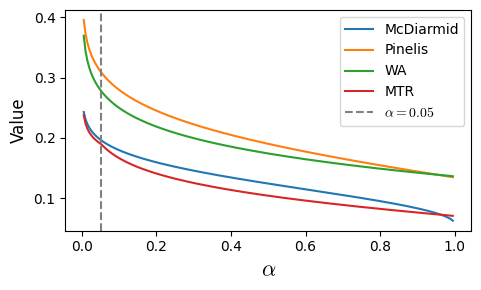

In [304]:
_, ax = plt.subplots(figsize=(5, 3))
_ = sns.lineplot(ax=ax, data=res, x="alpha", y="val", hue="name", markers=True)
_ = ax.axvline(0.05, color="grey", linestyle="--", label=rf"$\alpha=0.05$")
_ = ax.set_xlabel(rf"$\alpha$", fontsize=16)
_ = ax.set_ylabel("Value", fontsize=12)
_ = ax.legend(title="")
_ = plt.tight_layout()
# plt.savefig("../figs/dev_bound_comparison.pdf")

In [292]:
res.loc[lambda x: x["alpha"].le(0.05) & x["alpha"].ge(0.045)]

,name,val,alpha
10,McDiarmid,0.197008,0.05
210,Pinelis,0.310414,0.05
410,Wolfer,0.279303,0.05
610,MTR,0.190577,0.05


In [271]:
np.random.seed(2024)

nrep = 100
# pval_boot = []
# pval_mtr = []
rej_boot = []
rej_mtr = []
for _ in trange(nrep):
    xs = np.random.multivariate_normal(np.zeros(dim), np.eye(dim), n)
    weight_fn = kernels.PolyWeightFunction()
    kernel0 = kernels.IMQ(**{"sigma_sq": None, "med_heuristic": True, "X": xs, "Y": xs})
    kernel = kernels.TiltedKernel(kernel=kernel0, weight_fn=weight_fn)
    
    ksd = metrics.KSD(kernel)

    res = ksd.test_threshold(xs, score_fn(xs), theta=0.)
    # pval_boot.append(res["pval_standard"].item())
    rej_boot.append(res["pval_standard"] < alpha)

    mtr_threshold = ksd.compute_empirical_bernstein_threshold(xs, score_fn(xs), tau, alpha, c1=0.5).item()
    vstat = res["vstat"]
    rej_mtr.append(vstat**0.5 > mtr_threshold)
        

/home/clustor/ma/x/xl6116/research/robust-kernel-test/rksd/metrics.py:170: SyntaxWarning: invalid escape sequence '\g'
  Compute the threshold for the robust test. Threshold = \gamma + \theta.


  0%|          | 0/100 [00:00<?, ?it/s]

In [272]:
print("boot", np.array(rej_boot).mean())
print("MTR", np.array(rej_mtr).mean())

boot 0.07
MTR 0.0


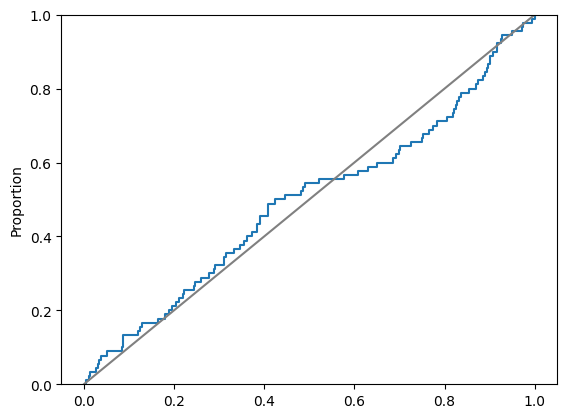

In [227]:
sns.ecdfplot(x=pval_boot)
plt.axline([0., 0.], slope=1., color="grey")